In [1]:
import numpy as np
import torch

# 1. 创建形状为3×4的随机矩阵X，标准正态分布
X = np.random.randn(3, 4)
print("X (3×4):\n", X)
print(f"X shape: {X.shape}\n")

# 2. 创建形状为4×2的全1矩阵Y
Y = np.ones((4, 2))
print("Y (4×2):\n", Y)
print(f"Y shape: {Y.shape}\n")

# 3. 计算矩阵乘法 Z = X × Y
Z = X @ Y
print("Z = X @ Y (3×2):\n", Z)
print(f"Z shape: {Z.shape}\n")

# 4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
print(f"Z[0, 1] (第一行第二列): {Z[0, 1]}")
print(f"Z[1, :] (第二行所有元素): {Z[1, :]}\n")

# 5. 计算Z的Frobenius范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print(f"Z的Frobenius范数: {frobenius_norm:.4f}")

# PyTorch版本（可选）
X_t = torch.randn(3, 4)
Y_t = torch.ones(4, 2)
Z_t = X_t @ Y_t
print(f"\nPyTorch Frobenius范数: {torch.norm(Z_t, 'fro').item():.4f}")

X (3×4):
 [[-0.79759656 -0.9935402   0.04978255  1.60564424]
 [-1.62499064  1.14108249  0.95064184  0.75621313]
 [-1.03944469 -0.01581217  1.24804367  2.31145443]]
X shape: (3, 4)

Y (4×2):
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Y shape: (4, 2)

Z = X @ Y (3×2):
 [[-0.13570997 -0.13570997]
 [ 1.22294681  1.22294681]
 [ 2.50424124  2.50424124]]
Z shape: (3, 2)

Z[0, 1] (第一行第二列): -0.1357099669039168
Z[1, :] (第二行所有元素): [1.22294681 1.22294681]

Z的Frobenius范数: 3.9459

PyTorch Frobenius范数: 4.8679


样本均值的实际方差: 0.000008
理论方差 (σ²/n): 0.000008
实际均值: 0.5000 (理论: 0.5)


C:\Users\曹佳瑶\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\曹佳瑶\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\曹佳瑶\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\曹佳瑶\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\曹佳瑶\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: User

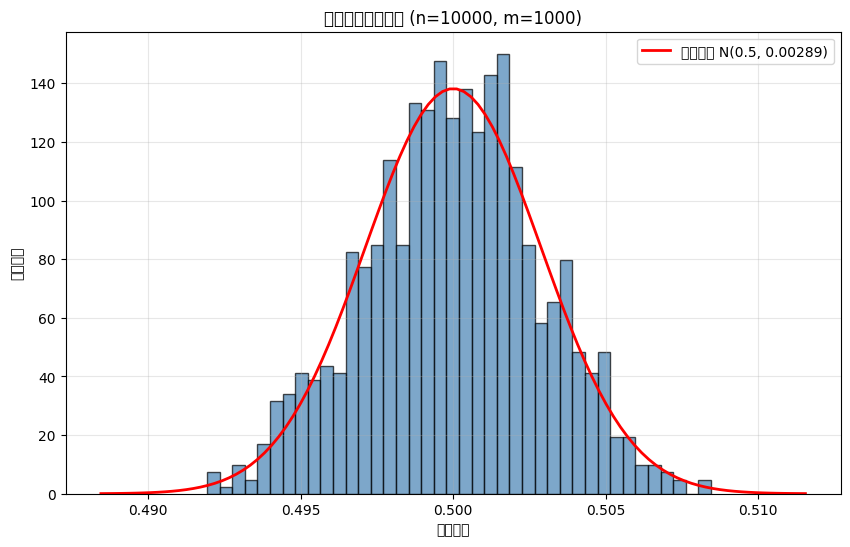

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# 参数设置
n = 10000      # 每次采样的样本数
m = 1000       # 采样次数

# 模拟中心极限定理
sample_means = []

for _ in range(m):
    samples = np.random.uniform(0, 1, n)
    sample_means.append(np.mean(samples))

sample_means = np.array(sample_means)

# 理论值
mu_theory = 0.5                    # U(0,1)的均值
sigma_theory = np.sqrt(1/12)       # U(0,1)的标准差
sigma_mean_theory = sigma_theory / np.sqrt(n)  # 均值的标准差

# 绘制直方图
plt.figure(figsize=(10, 6))
count, bins, _ = plt.hist(sample_means, bins=40, density=True, 
                          alpha=0.7, color='steelblue', edgecolor='black')

# 叠加理论正态分布曲线
x = np.linspace(mu_theory - 4*sigma_mean_theory, 
                mu_theory + 4*sigma_mean_theory, 100)
pdf = stats.norm.pdf(x, mu_theory, sigma_mean_theory)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'正态分布 N({mu_theory}, {sigma_mean_theory:.5f})')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'中心极限定理验证 (n={n}, m={m})')
plt.legend()
plt.grid(alpha=0.3)

# 计算实际方差
actual_variance = np.var(sample_means)
print(f"样本均值的实际方差: {actual_variance:.6f}")
print(f"理论方差 (σ²/n): {(1/12)/n:.6f}")
print(f"实际均值: {np.mean(sample_means):.4f} (理论: 0.5)")

plt.show()

In [3]:
import torch

# 手动实现计算图的反向传播
def forward_manual(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return L, a, b

# 手动计算梯度（链式法则）
def backward_manual(x, w1, w2, L, a, b):
    dL_db = 2 * b          # ∂L/∂b = 2b
    db_da = 1              # ∂b/∂a = 1
    db_dw2 = 1             # ∂b/∂w2 = 1
    da_dw1 = x             # ∂a/∂w1 = x
    
    dL_dw2 = dL_db * db_dw2
    dL_dw1 = dL_db * db_da * da_dw1
    
    return dL_dw1, dL_dw2

# 给定参数
x, w1, w2 = 2.0, 1.5, 0.5

# 前向计算
L, a, b = forward_manual(x, w1, w2)
print(f"前向计算: a={a}, b={b}, L={L}")

# 手动反向传播
grad_w1_manual, grad_w2_manual = backward_manual(x, w1, w2, L, a, b)
print(f"\n手动计算梯度:")
print(f"  ∂L/∂w1 = {grad_w1_manual}")
print(f"  ∂L/∂w2 = {grad_w2_manual}")

# PyTorch自动微分验证
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"\nPyTorch自动微分:")
print(f"  ∂L/∂w1 = {w1_t.grad.item()}")
print(f"  ∂L/∂w2 = {w2_t.grad.item()}")

# 验证一致性
assert abs(grad_w1_manual - w1_t.grad.item()) < 1e-6
assert abs(grad_w2_manual - w2_t.grad.item()) < 1e-6
print("\n✓ 手动梯度与自动微分结果一致！")

前向计算: a=3.0, b=3.5, L=12.25

手动计算梯度:
  ∂L/∂w1 = 14.0
  ∂L/∂w2 = 7.0

PyTorch自动微分:
  ∂L/∂w1 = 14.0
  ∂L/∂w2 = 7.0

✓ 手动梯度与自动微分结果一致！


Softmax 回归 - Fashion-MNIST 分类

1. 加载 Fashion-MNIST 数据...
   训练集大小: 5000
   测试集大小: 10000
   图像维度: 784
   类别数: 10

2. 划分训练集和验证集...
   训练集: 4000 样本
   验证集: 1000 样本

3. 创建 Softmax 回归模型...

4. 开始训练...
----------------------------------------
Epoch  10/50, Loss: 0.5159, Val Acc: 0.8220
Epoch  20/50, Loss: 0.4304, Val Acc: 0.8170
Epoch  30/50, Loss: 0.3889, Val Acc: 0.8330
Epoch  40/50, Loss: 0.3664, Val Acc: 0.8320
Epoch  50/50, Loss: 0.3486, Val Acc: 0.8340

5. 测试评估...
   测试集准确率: 0.8234 (82.34%)


C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\559927635.py:216: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\559927635.py:216: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\559927635.py:216: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\559927635.py:216: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\559927635.py:216: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\559927635.py:216: UserWarning: Glyph 32447 (\N{CJK UNIFIE

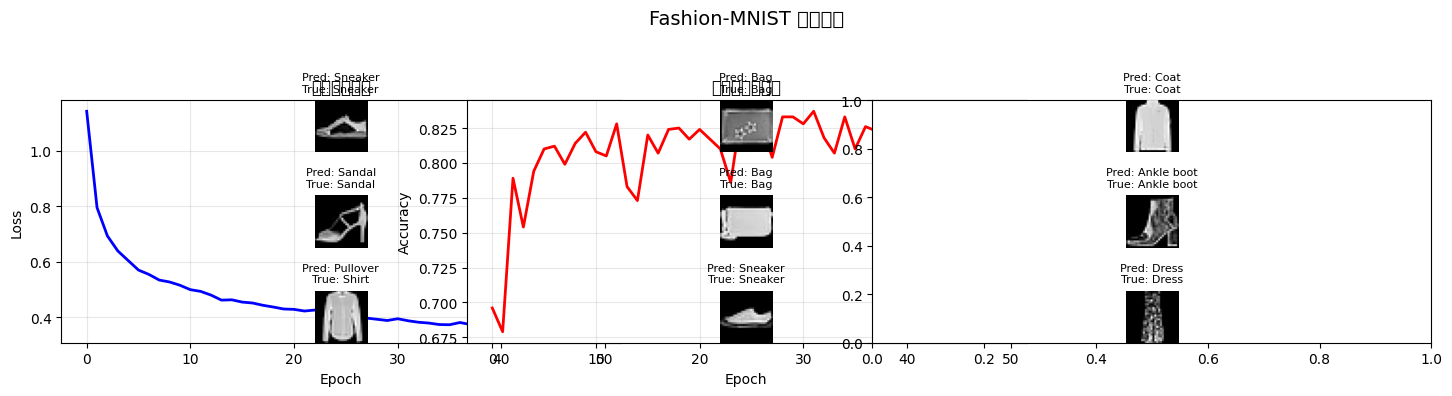


6. 混淆矩阵分析


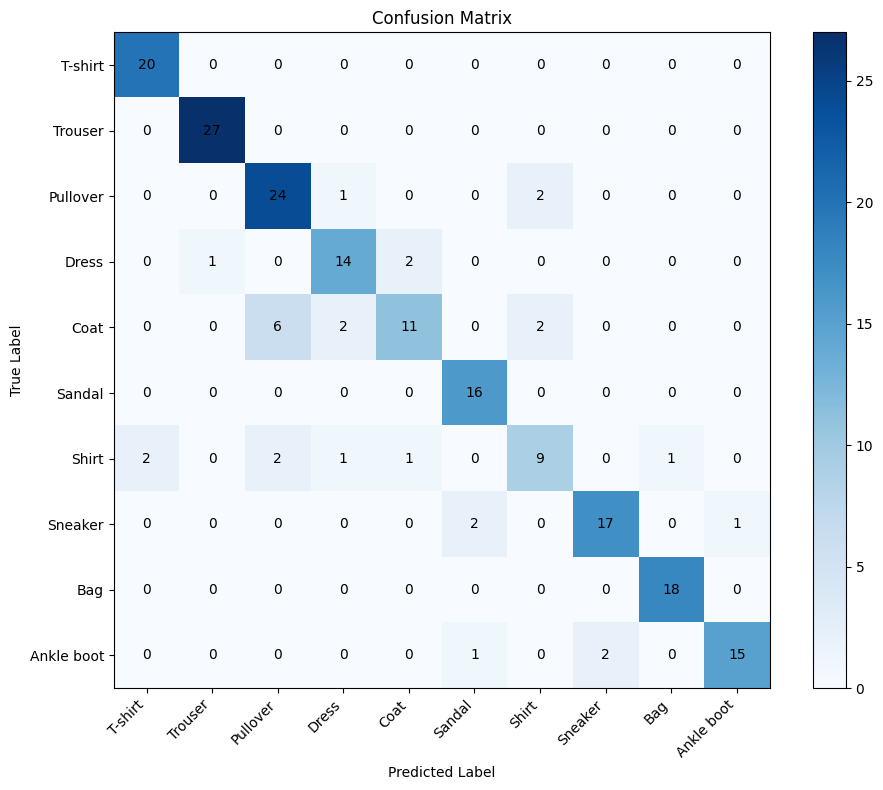

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms

# ============ 使用 PyTorch 加载 Fashion-MNIST ============

def load_fashion_mnist(batch_size=64):
    """加载 Fashion-MNIST 数据集"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))  # 展平为向量
    ])
    
    # 下载数据集
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=transform, download=True)
    
    # 转换为 numpy
    X_train = train_dataset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
    y_train = train_dataset.targets.numpy()
    X_test = test_dataset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
    y_test = test_dataset.targets.numpy()
    
    return X_train, y_train, X_test, y_test


# ============ Softmax 回归实现 ============

class SoftmaxRegression:
    def __init__(self, input_dim, num_classes, lr=0.1):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros(num_classes)
        self.lr = lr
    
    def softmax(self, logits):
        """数值稳定的 Softmax"""
        logits_shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(logits_shifted)
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, probs, y_onehot):
        """交叉熵损失"""
        eps = 1e-8
        return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))
    
    def forward(self, X):
        """前向传播"""
        logits = X @ self.W + self.b
        return self.softmax(logits)
    
    def backward(self, X, y_onehot, probs):
        """反向传播计算梯度"""
        m = X.shape[0]
        grad_logits = (probs - y_onehot) / m
        grad_W = X.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0)
        return grad_W, grad_b
    
    def update(self, grad_W, grad_b):
        """SGD 参数更新"""
        self.W -= self.lr * grad_W
        self.b -= self.lr * grad_b
    
    def train(self, X_train, y_train_onehot, X_val, y_val, 
              batch_size=32, epochs=50, verbose=True):
        """训练模型"""
        n = X_train.shape[0]
        train_losses = []
        val_accs = []
        
        for epoch in range(epochs):
            indices = np.random.permutation(n)
            epoch_loss = 0
            num_batches = 0
            
            for i in range(0, n, batch_size):
                batch_idx = indices[i:i+batch_size]
                X_batch = X_train[batch_idx]
                y_batch = y_train_onehot[batch_idx]
                
                probs = self.forward(X_batch)
                loss = self.cross_entropy_loss(probs, y_batch)
                grad_W, grad_b = self.backward(X_batch, y_batch, probs)
                self.update(grad_W, grad_b)
                
                epoch_loss += loss
                num_batches += 1
            
            avg_loss = epoch_loss / num_batches
            train_losses.append(avg_loss)
            
            val_acc = self.evaluate(X_val, y_val)
            val_accs.append(val_acc)
            
            if verbose and (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:3d}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        return train_losses, val_accs
    
    def predict(self, X):
        """预测类别"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    
    def evaluate(self, X, y):
        """计算准确率"""
        preds = self.predict(X)
        return np.mean(preds == y)


def one_hot_encode(y, num_classes):
    """One-hot 编码"""
    n = len(y)
    y_onehot = np.zeros((n, num_classes))
    y_onehot[np.arange(n), y] = 1
    return y_onehot


def train_val_split(X, y, val_ratio=0.2):
    """手动划分训练集和验证集"""
    n = len(X)
    indices = np.random.permutation(n)
    val_size = int(n * val_ratio)
    
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    return X[train_indices], y[train_indices], X[val_indices], y[val_indices]


# ============ 主程序 ============

def main():
    print("=" * 60)
    print("Softmax 回归 - Fashion-MNIST 分类")
    print("=" * 60)
    
    # 加载数据
    print("\n1. 加载 Fashion-MNIST 数据...")
    X_train_full, y_train_full, X_test, y_test = load_fashion_mnist()
    
    # 使用子集加速训练
    sample_size = 5000
    indices = np.random.choice(len(X_train_full), sample_size, replace=False)
    X_train_full = X_train_full[indices]
    y_train_full = y_train_full[indices]
    
    print(f"   训练集大小: {X_train_full.shape[0]}")
    print(f"   测试集大小: {X_test.shape[0]}")
    print(f"   图像维度: {X_train_full.shape[1]}")
    print(f"   类别数: {len(np.unique(y_train_full))}")
    
    # 划分验证集
    print("\n2. 划分训练集和验证集...")
    X_train, y_train, X_val, y_val = train_val_split(X_train_full, y_train_full, val_ratio=0.2)
    print(f"   训练集: {X_train.shape[0]} 样本")
    print(f"   验证集: {X_val.shape[0]} 样本")
    
    # One-hot 编码
    num_classes = 10
    y_train_onehot = one_hot_encode(y_train, num_classes)
    
    # 创建模型
    print("\n3. 创建 Softmax 回归模型...")
    input_dim = X_train.shape[1]
    model = SoftmaxRegression(input_dim=input_dim, num_classes=num_classes, lr=0.1)
    
    # 训练模型
    print("\n4. 开始训练...")
    print("-" * 40)
    train_losses, val_accs = model.train(
        X_train, y_train_onehot, X_val, y_val,
        batch_size=64, epochs=50, verbose=True
    )
    
    # 测试评估
    print("\n5. 测试评估...")
    test_acc = model.evaluate(X_test, y_test)
    print(f"   测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")
    
    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # 损失曲线
    axes[0].plot(train_losses, 'b-', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('训练损失曲线')
    axes[0].grid(True, alpha=0.3)
    
    # 验证准确率曲线
    axes[1].plot(val_accs, 'r-', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('验证准确率曲线')
    axes[1].grid(True, alpha=0.3)
    
    # 展示部分预测结果
    class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    sample_indices = np.random.choice(len(X_test), 9, replace=False)
    for i, idx in enumerate(sample_indices):
        ax = plt.subplot(3, 3, i+1)
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        pred = model.predict(X_test[idx].reshape(1, -1))[0]
        true_label = y_test[idx]
        ax.set_title(f'Pred: {class_names[pred]}\nTrue: {class_names[true_label]}', fontsize=8)
        ax.axis('off')
    plt.suptitle('Fashion-MNIST 预测示例', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('softmax_fashion_mnist.png', dpi=150)
    plt.show()
    
    # 打印混淆矩阵
    print("\n" + "=" * 60)
    print("6. 混淆矩阵分析")
    print("=" * 60)
    y_pred = model.predict(X_test)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test[:200], y_pred[:200])
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.xticks(range(10), class_names, rotation=45, ha='right')
    plt.yticks(range(10), class_names)
    
    # 添加数值标注
    for i in range(10):
        for j in range(10):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    
    return model


if __name__ == "__main__":
    model = main()

Iter 200, Loss: 0.3232
Iter 400, Loss: 0.3145
Iter 600, Loss: 0.3102
Iter 800, Loss: 0.3075
Iter 1000, Loss: 0.3057

训练集准确率: 0.8812
测试集准确率: 0.8750


C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\2631758498.py:108: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\2631758498.py:108: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\2631758498.py:108: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\2631758498.py:108: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\2631758498.py:108: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\曹佳瑶\AppData\Local\Temp\ipykernel_23736\2631758498.py:108: UserWarning: Glyph 32451 (\N{CJK 

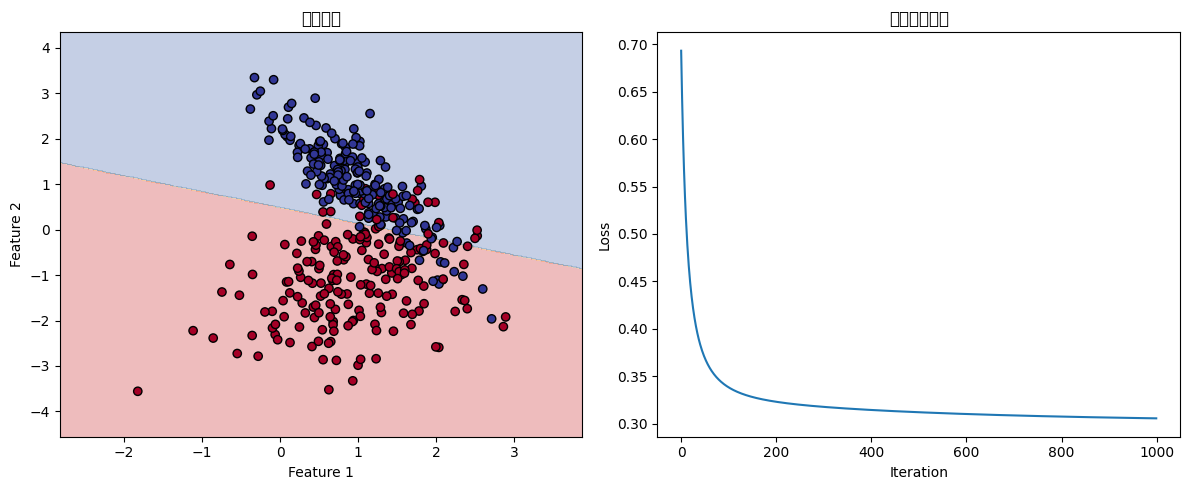

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

class LogisticRegression:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
    
    def sigmoid(self, z):
        # 数值稳定版本
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_true, y_pred):
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        losses = []
        
        for i in range(self.n_iters):
            # 前向传播
            linear = X @ self.w + self.b
            predictions = self.sigmoid(linear)
            
            # 计算损失
            loss = self.binary_cross_entropy(y, predictions)
            losses.append(loss)
            
            # 梯度计算
            dw = (1 / n_samples) * (X.T @ (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)
            
            # 参数更新
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            if (i + 1) % 200 == 0:
                print(f"Iter {i+1}, Loss: {loss:.4f}")
        
        return losses
    
    def predict_proba(self, X):
        linear = X @ self.w + self.b
        return self.sigmoid(linear)
    
    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)


# 生成线性可分数据
np.random.seed(42)
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, random_state=42)

# 划分训练集和测试集
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 训练模型
model = LogisticRegression(lr=0.1, n_iters=1000)
losses = model.fit(X_train, y_train)

# 评估
train_acc = model.accuracy(X_train, y_train)
test_acc = model.accuracy(X_test, y_test)
print(f"\n训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

# 绘制决策边界
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('决策边界')
    
    plt.subplot(1, 2, 2)
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('训练损失曲线')
    
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X, y, model)